# Random forest regression
Random forest is (like many other models) implemented in Scikit library. Its syntax is analogous to the regression tree models you have already seen.

## Data
Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]

Individual medical costs billed by health insurance

EDA: e.g [https://datauab.github.io/medical_insurance/]

In this notebook, we will demonstrate basic syntax of **scikit** library.
There are many popular data science modes in this library.

The basic syntax is a **instantiate->fit->predict** sequence.

In [1]:
### Dependencies
import pandas as pd #data frames and other stuff
import matplotlib.pyplot as plt #basic graphs
import pickle

# Usefull functions
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error # MSE

# Used models
# Used models
from sklearn.ensemble import RandomForestRegressor

#Set the seed of the random number generator
SEED = 500

In [2]:
# import gdown
#In colab, you need to download the file first and save it locally
# file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
file_path = '../data/insurance_train_test.pkl'
# gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

Load the data

In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error
#for local installation / VM horizon
file_path = '../data/insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train,X_test, y_train, y_test = pickle.load(input_file)

# Fit the first model
Use the following hyper parameters:  n_estimators = 100, min_sample_split = 0.05, max_features = 4

In [10]:
#Set the HP


# Instantiate RandomForestRegressor 'rf'

# Fit the model to the training set

# Predict the test set labels 'y_pred'

# Evaluate the test set RMSE

# Instantiate the RandomForestRegressor with initial hyperparameters
rf = RandomForestRegressor(n_estimators=100, min_samples_split=0.05, max_features=4, random_state=SEED)

# Fit the model
rf.fit(X_train, y_train.values.ravel())

# Predict test set labels
y_pred = rf.predict(X_test)

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Original test set RMSE of rf: {rmse:.2f}')


Original test set RMSE of rf: 4195.70


## Optimize the HP
Optimize the hyper parameters on some grid. Note that RF has higher numebr of HP than the decision tree and also that instead of one tree, you fit an ensamble of trees. (The forest actually :-) ). Fitting will take longer.

In [11]:
# Create the grid

#reinstantiate RandomForestRegressor regressor with empty hyper parameter set


# Instantiate the GridSearchCV with random fores as estimator and 3-fold cross validation

# Hyperparameter optimization
param_grid = {
    'n_estimators': [50, 100, 200],
    'min_samples_split': [0.02, 0.05, 0.1],
    'max_features': [2, 4, 6]
}

# Instantiate GridSearchCV
rf_grid = GridSearchCV(RandomForestRegressor(random_state=SEED), param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit grid search
rf_grid.fit(X_train, y_train.values.ravel())

# Get best parameters and best estimator
best_params = rf_grid.best_params_
best_rf = rf_grid.best_estimator_

# Predict test set labels using optimized model
y_pred_opt = best_rf.predict(X_test)
rmse_test_cv = np.sqrt(mean_squared_error(y_test, y_pred_opt))

print(f'Optimized test set RMSE of rf: {rmse_test_cv:.2f}')


Optimized test set RMSE of rf: 3671.01


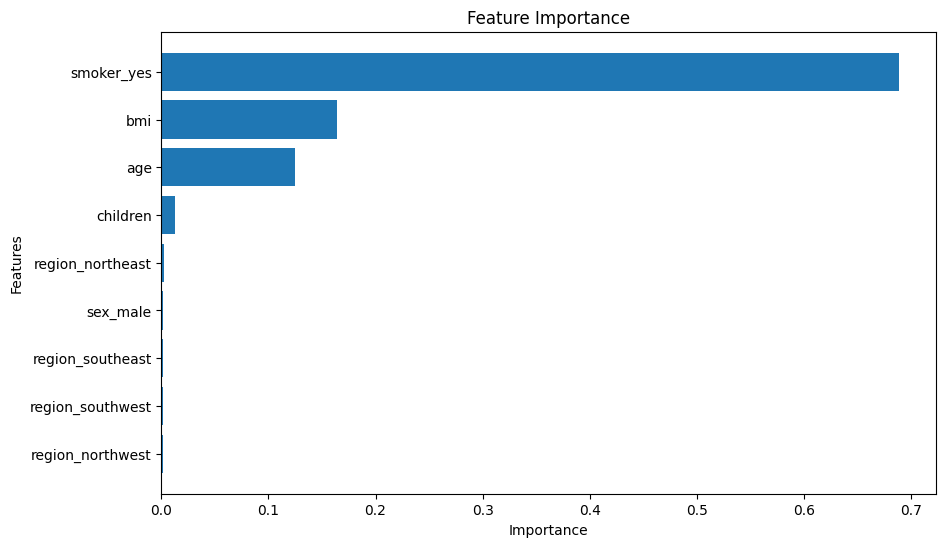

In [12]:
# Feature importance plot
importances = best_rf.feature_importances_
sorted_index = np.argsort(importances)
labels = X_train.columns[sorted_index]

plt.figure(figsize=(10, 6))
plt.barh(range(X_train.shape[1]), importances[sorted_index], tick_label=labels)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [13]:
# Fit the grid search to the data

#best parameters

#best estimator

# Predict the test set labels 'y_pred'


print('------------------------------------')
print(f'Original test set RMSE of rf: {rmse:.2f}')
print(f'Optimized test set RMSE of rf: {rmse_test_cv:.2f}')

------------------------------------
Original test set RMSE of rf: 4195.70
Optimized test set RMSE of rf: 3671.01
